In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [8]:
df["TotalCharges"].unique()

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

In [9]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

In [10]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### Observation: TotalCharges

`TotalCharges` is stored as a string instead of a numeric variable.

After converting it to numeric format, 11 missing values were identified.
All 11 observations correspond to customers with `tenure = 0`, suggesting
that these are newly registered customers who have not yet accumulated charges.

This issue will be handled during the preprocessing stage.

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Numerical Features - Initial Observations

- The dataset contains 7,043 customers.
- `SeniorCitizen` is a binary categorical feature encoded as 0/1. Approximately
  16.2% of customers are senior citizens.
- `tenure` ranges from 0 to 72 months, with an average of 32.4 months and a
  median of 29 months. This indicates substantial variability in customer tenure.
- `MonthlyCharges` ranges from 18.25 to 118.75, with an average monthly charge
  of 64.76 and a median of 70.35.
- Distribution shapes cannot be determined conclusively from descriptive
  statistics alone and will be investigated using visualizations.

## Distribution of Numerical Features

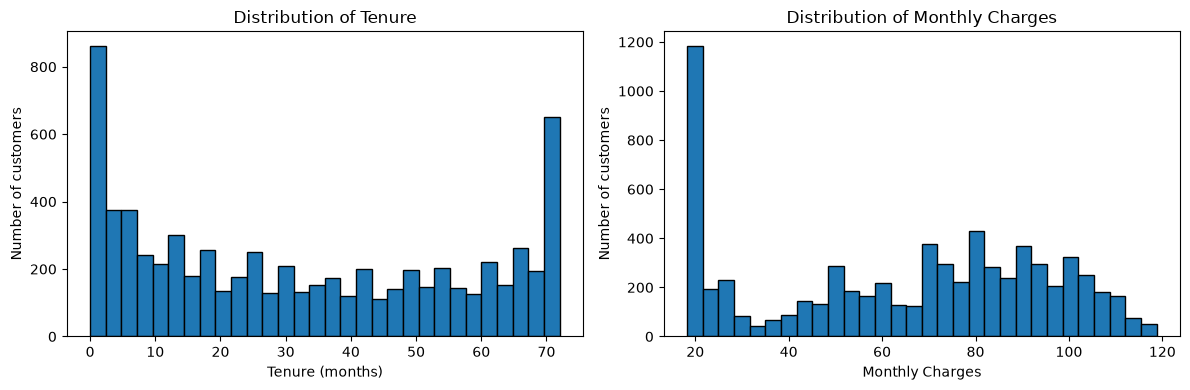

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["tenure"], bins=30, edgecolor="black")
axes[0].set_title("Distribution of Tenure")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Number of customers")

axes[1].hist(df["MonthlyCharges"], bins=30, edgecolor="black")
axes[1].set_title("Distribution of Monthly Charges")
axes[1].set_xlabel("Monthly Charges")
axes[1].set_ylabel("Number of customers")

plt.tight_layout()
plt.show()

### Distribution Analysis

**Tenure**
- The distribution of `tenure` is not normally distributed.
- A high concentration of customers is observed at very low tenure values,
  indicating a large group of newly acquired customers.
- Another concentration appears around 70–72 months, representing long-term customers.
- This suggests that customer tenure may be an important feature for churn prediction.

**Monthly Charges**
- `MonthlyCharges` also shows a non-normal distribution.
- There is a strong concentration of customers with relatively low monthly charges,
  around 20–25.
- The remaining customers are distributed across several higher charge ranges.
- These different groups may reflect different service subscriptions or customer plans.

In [13]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

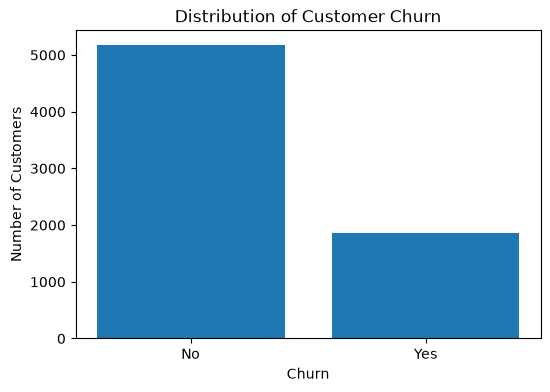

In [15]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Target Variable Analysis

- 73.46% of customers did not churn, while 26.54% churned.
- The target variable therefore presents a moderate class imbalance.
- This imbalance should be considered during model evaluation, since accuracy
  alone may provide a misleading assessment of model performance.
- Metrics such as precision, recall, F1-score, and ROC-AUC will also be considered.

In [16]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [17]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

In [18]:
churn_by_tenure = (
    df.groupby("tenure_group", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

churn_by_tenure

tenure_group
0-12 months     47.438243
13-24 months    28.710938
25-48 months    20.388959
49-72 months     9.513176
Name: Churn, dtype: float64

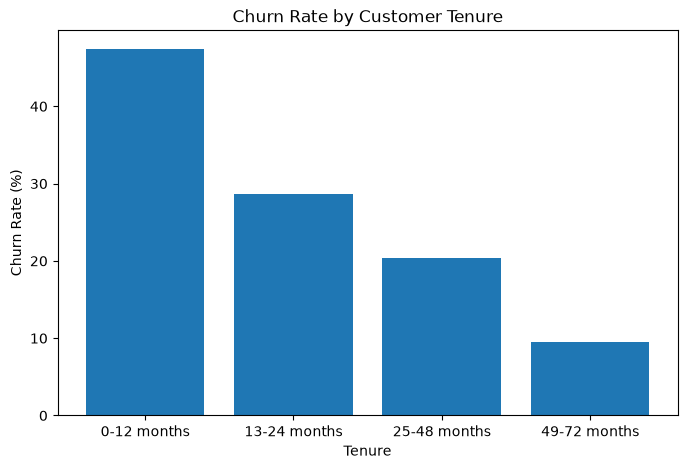

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(churn_by_tenure.index, churn_by_tenure.values)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")

plt.show()

### Churn Rate by Tenure

- The churn rate decreases substantially as customer tenure increases.
- Customers in their first 12 months have the highest churn rate, at approximately 47%.
- In contrast, customers with 49–72 months of tenure have a churn rate of only about 9%.
- This suggests that newly acquired customers are particularly vulnerable to churn.
- Customer tenure therefore appears to be a potentially important predictor of churn.

In [20]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [21]:
churn_by_contract = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

churn_by_contract

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

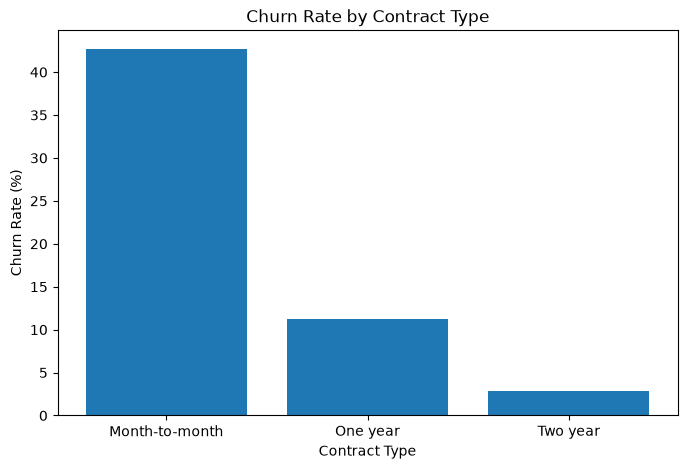

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(churn_by_contract.index, churn_by_contract.values)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

### Churn Rate by Contract Type

- Month-to-month customers have the highest churn rate, at approximately 43%.
- The churn rate decreases substantially for one-year contracts (~11%) and
  two-year contracts (~3%).
- Contract type therefore appears to be strongly associated with customer churn.
- Month-to-month customers represent a potential priority segment for retention
  strategies.
- The company could test incentives encouraging customers to adopt longer-term
  contracts and evaluate their impact through controlled experiments.

In [23]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


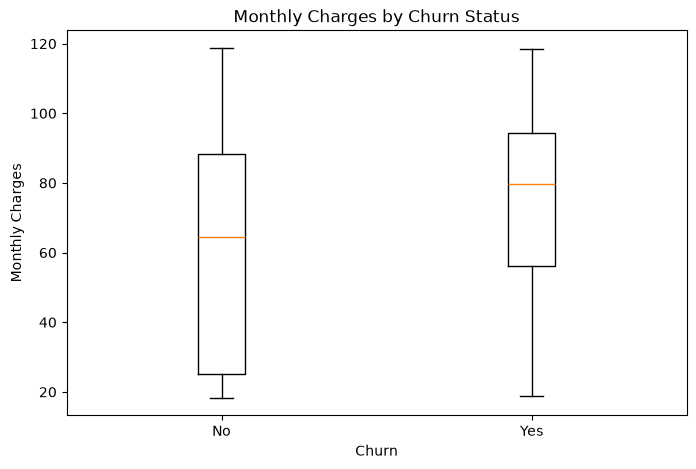

In [24]:
churn_no = df[df["Churn"] == "No"]["MonthlyCharges"]
churn_yes = df[df["Churn"] == "Yes"]["MonthlyCharges"]

plt.figure(figsize=(8, 5))

plt.boxplot(
    [churn_no, churn_yes],
    tick_labels=["No", "Yes"]
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Monthly Charges and Churn

- Customers who churn tend to have higher monthly charges than customers who remain.
- The median monthly charge is higher among churned customers.
- However, the distributions overlap substantially, indicating that monthly charges
  alone do not clearly separate churners from non-churners.
- Monthly charges appear to be associated with churn, but this relationship should
  be investigated together with other customer characteristics and services.

In [25]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [26]:
churn_by_internet = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

churn_by_internet

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64

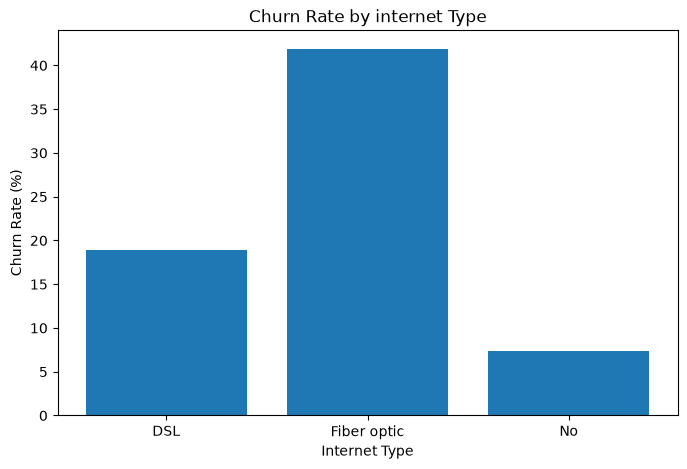

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(churn_by_internet.index, churn_by_internet.values)

plt.title("Churn Rate by internet Type")
plt.xlabel("Internet Type")
plt.ylabel("Churn Rate (%)")

plt.show()

In [29]:
df.groupby("InternetService")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
InternetService,,,,,,,,
DSL,2421.0,58.102169,16.259522,23.45,46.20,56.150,69.90,94.80
Fiber optic,3096.0,91.500129,12.663039,67.75,80.55,91.675,101.15,118.75
No,1526.0,21.079194,2.164221,18.25,19.70,20.150,20.90,26.90


### Internet Service, Monthly Charges and Churn

- Fiber optic customers have the highest churn rate (~42%), compared with
  DSL customers (~19%) and customers without internet service (~7%).
- Fiber optic customers also have substantially higher monthly charges, with
  an average of approximately 91.5, compared with 58.1 for DSL customers
  and 21.1 for customers without internet service.
- This suggests that the relationship between internet service and churn may
  interact with pricing and other customer characteristics.
- These results show association rather than causation; further multivariate
  analysis is required before drawing causal conclusions.

In [30]:
df["TechSupport"].value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [31]:
churn_by_support = (
    df.groupby("TechSupport")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

churn_by_support

TechSupport
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Churn, dtype: float64

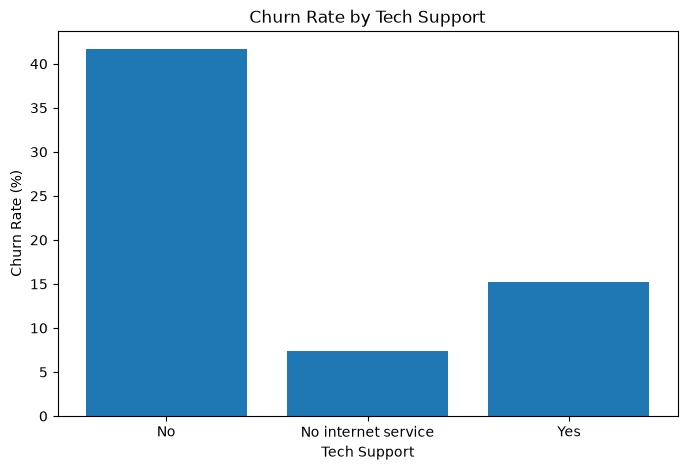

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    churn_by_support.index,
    churn_by_support.values
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

plt.show()

In [33]:
df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [35]:
churn_by_security = (
    df.groupby("OnlineSecurity")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

churn_by_security

OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Churn, dtype: float64

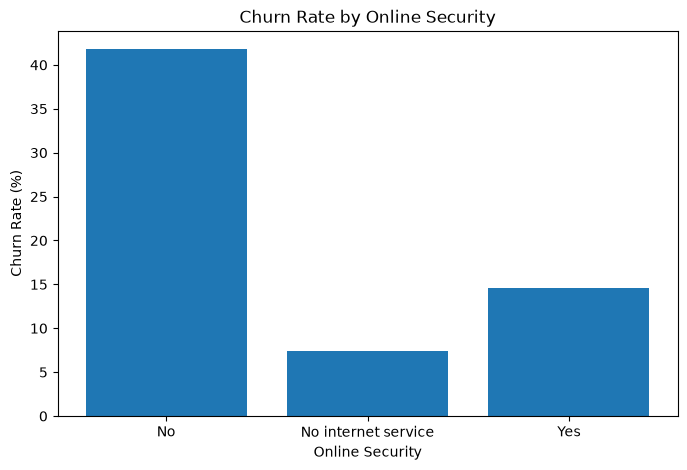

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    churn_by_security.index,
    churn_by_security.values
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

plt.show()

### Online Security and Churn

- Customers without online security have the highest churn rate, at approximately 42%.
- Customers with online security have a substantially lower churn rate, at approximately 15%.
- The pattern is very similar to the one observed for `TechSupport`.
- Both `OnlineSecurity` and `TechSupport` appear to be strongly associated with customer retention.
- However, these relationships should not be interpreted as causal at this stage.

In [37]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [38]:
churn_by_payment = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

churn_by_payment

PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn, dtype: float64

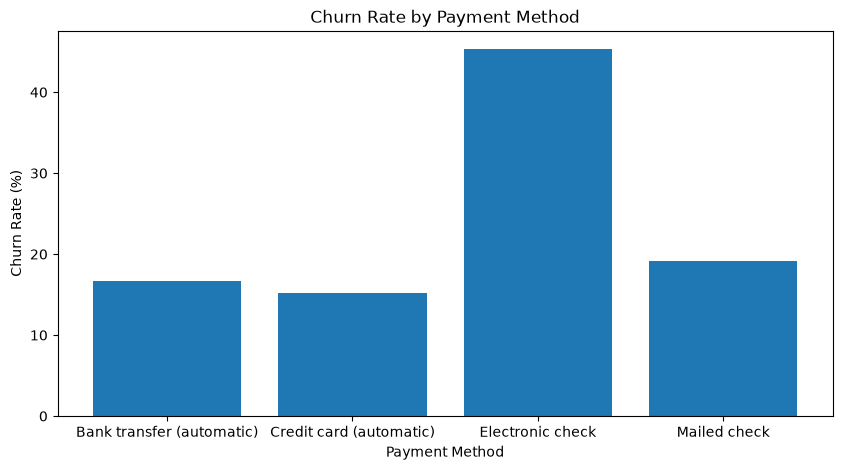

In [47]:
plt.figure(figsize=(10, 5))

plt.bar(
    churn_by_payment.index,
    churn_by_payment.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.show()

### Payment Method and Churn

- Customers using electronic checks have the highest churn rate, at approximately 45%.
- Customers using automatic payment methods have substantially lower churn rates,
  around 15–17%.
- Electronic check users therefore appear to represent a higher-risk customer segment.
- However, this relationship should be interpreted together with other features such
  as contract type, tenure, and internet service.

In [48]:
df["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [49]:
churn_by_paperless = (
    df.groupby("PaperlessBilling")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

churn_by_paperless

PaperlessBilling
No     16.330084
Yes    33.565092
Name: Churn, dtype: float64

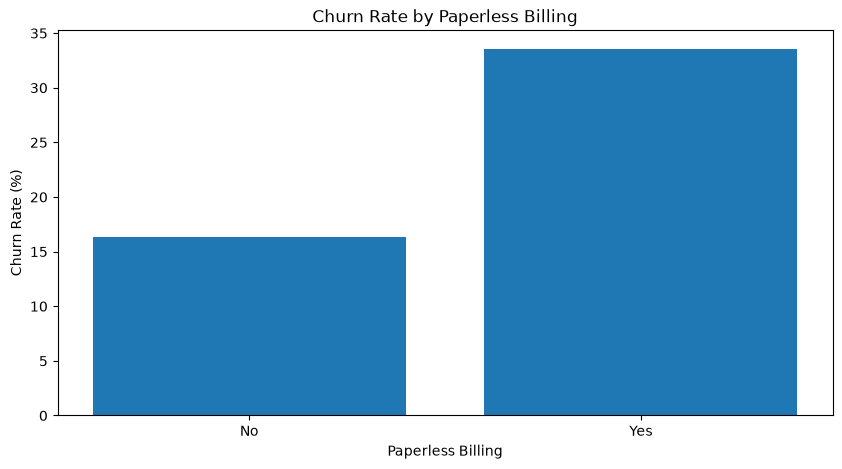

In [50]:
plt.figure(figsize=(10, 5))

plt.bar(
    churn_by_paperless.index,
    churn_by_paperless.values
)

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")

plt.show()

### Paperless Billing and Churn

- Customers using paperless billing have a churn rate of approximately 34%,
  compared with about 16% for customers without paperless billing.
- Paperless billing is therefore associated with a higher churn rate.
- However, this relationship should not be interpreted as causal, since
  paperless billing may also be associated with other customer characteristics.

## EDA Summary

The exploratory data analysis highlighted several customer characteristics
associated with churn:

- **Customer tenure:** Churn is substantially higher among recently acquired
  customers. Customers in their first 12 months have a churn rate of approximately
  47%, while customers with 49–72 months of tenure have a much lower churn rate.

- **Contract type:** Month-to-month customers show the highest churn rate (~43%),
  compared with one-year (~11%) and two-year contracts (~3%).

- **Monthly charges:** Customers who churn tend to have higher monthly charges,
  although the distributions of churners and non-churners overlap substantially.

- **Internet service:** Fiber optic customers have the highest churn rate (~42%)
  and also substantially higher monthly charges than DSL customers.

- **Support and security services:** Customers without TechSupport or OnlineSecurity
  show considerably higher churn rates than customers subscribed to these services.

- **Payment method:** Electronic check customers have the highest churn rate (~45%),
  while automatic payment methods are associated with substantially lower rates.

- **Paperless billing:** Customers using paperless billing show a higher churn rate
  than customers without paperless billing.

Overall, churn appears to be particularly associated with short tenure,
month-to-month contracts, fiber optic service, lack of support/security services,
electronic check payments, and higher monthly charges.

These findings represent associations rather than causal relationships.
The next stage will prepare the data and evaluate whether these features remain
useful when considered jointly in machine learning models.